Using device: cpu
CSE366 Mini Project: Medicinal Plants Classification
TASK 4: Attention-Enhanced CNN
TASK 4: Attention-Enhanced CNN (CBAM)

1. Preparing Data...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Total samples: 3494
Training samples: 2445
Validation samples: 524
Test samples: 525
Number of classes: 16
Classes: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']

2. Initializing Attention-Enhanced CNN (CBAM)...
Total parameters: 2,140,568
Trainable parameters: 2,140,568

3. Starting Training...
Epoch  |  Train Loss  | Train Acc  |   Val Loss   |  Val Acc   |   Time  
----------------------------------------------------------------------


Training: 100%|██████████| 77/77 [06:20<00:00,  4.94s/it, Loss=0.6714, Acc=62.99%]


  1    |    1.1331    |   62.99    |    1.2209    |   61.26    |  414.52 
✓ New best model saved with validation accuracy: 61.26%


...

  4    |    0.2084    |   93.29    |    1.4416    |   58.78    |  386.39 


Training: 100%|██████████| 77/77 [05:56<00:00,  4.63s/it, Loss=0.3201, Acc=93.37%]


  5    |    0.1871    |   93.37    |    0.4298    |   84.73    |  384.79 
✓ New best model saved with validation accuracy: 84.73%

Training completed in 1955.60 seconds
Best validation accuracy: 84.73%

4. Loading Best Model and Evaluating...


Evaluating: 100%|██████████| 17/17 [00:34<00:00,  2.01s/it]



5. Generating Evaluation Reports...

Detailed Classification Report:
              precision    recall  f1-score   support

      type_1       0.82      0.97      0.89        29
     type_10       0.64      1.00      0.78        16
     type_11       1.00      0.84      0.91        80
     type_12       1.00      0.75      0.86        12
     type_13       0.81      0.84      0.82        25
     type_14       0.38      1.00      0.55        20
     type_15       1.00      1.00      1.00        13
     type_16       0.79      1.00      0.88        42
      type_2       1.00      0.69      0.82        26
      type_3       0.95      0.88      0.92        43
      type_4       0.95      0.64      0.76        33
      type_5       0.74      0.89      0.81        19
      type_6       0.86      0.89      0.88        36
      type_7       0.74      0.65      0.69        40
      type_8       0.88      0.70      0.78        50
      type_9       0.97      0.71      0.82        41

    accura

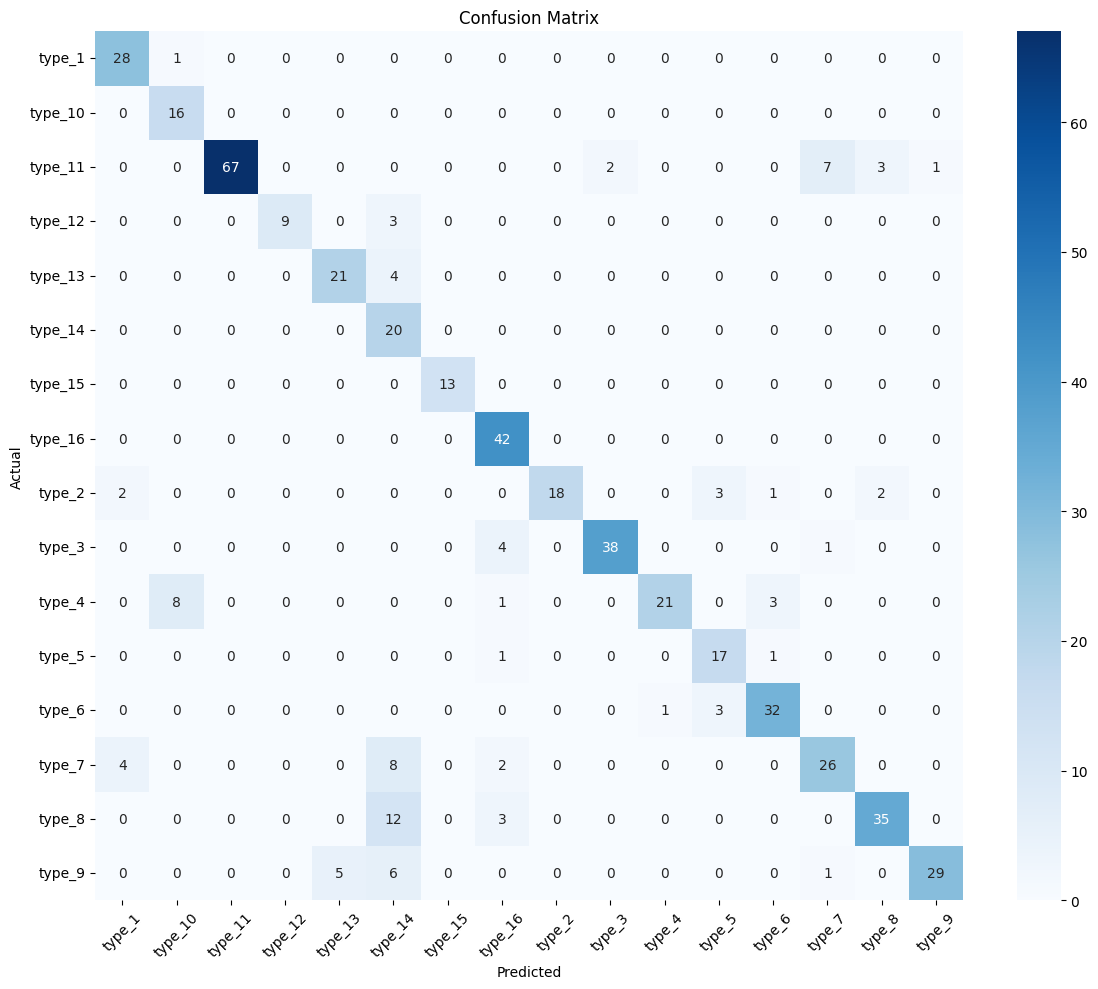

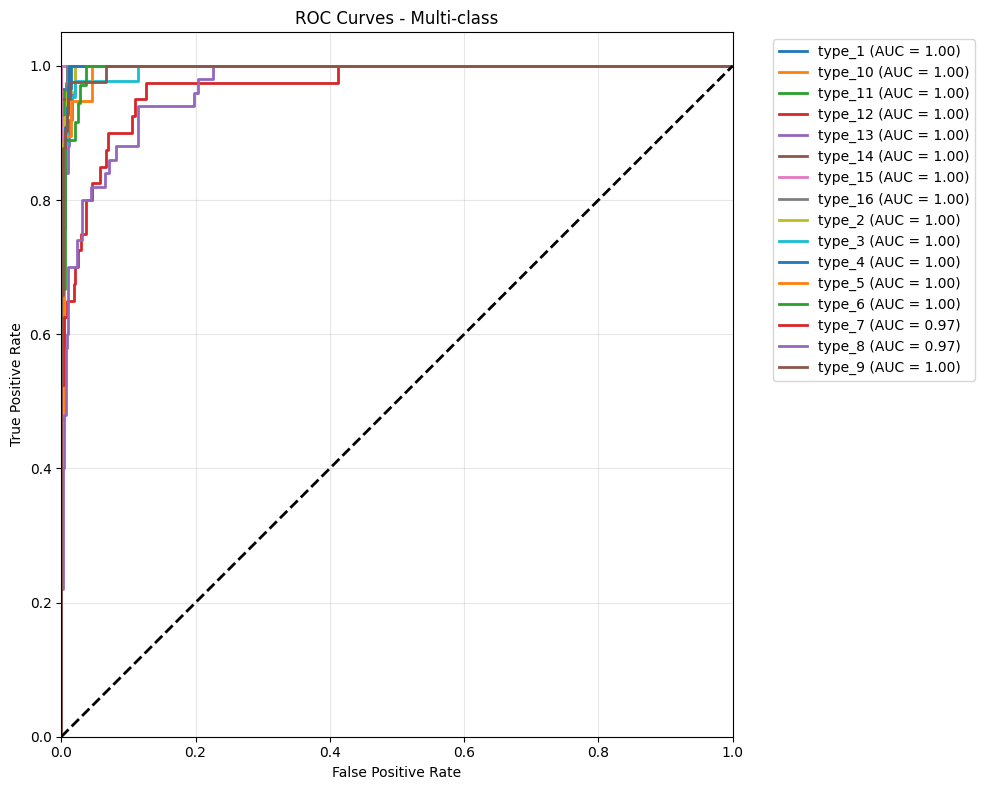

Macro Average ROC AUC: 0.9947


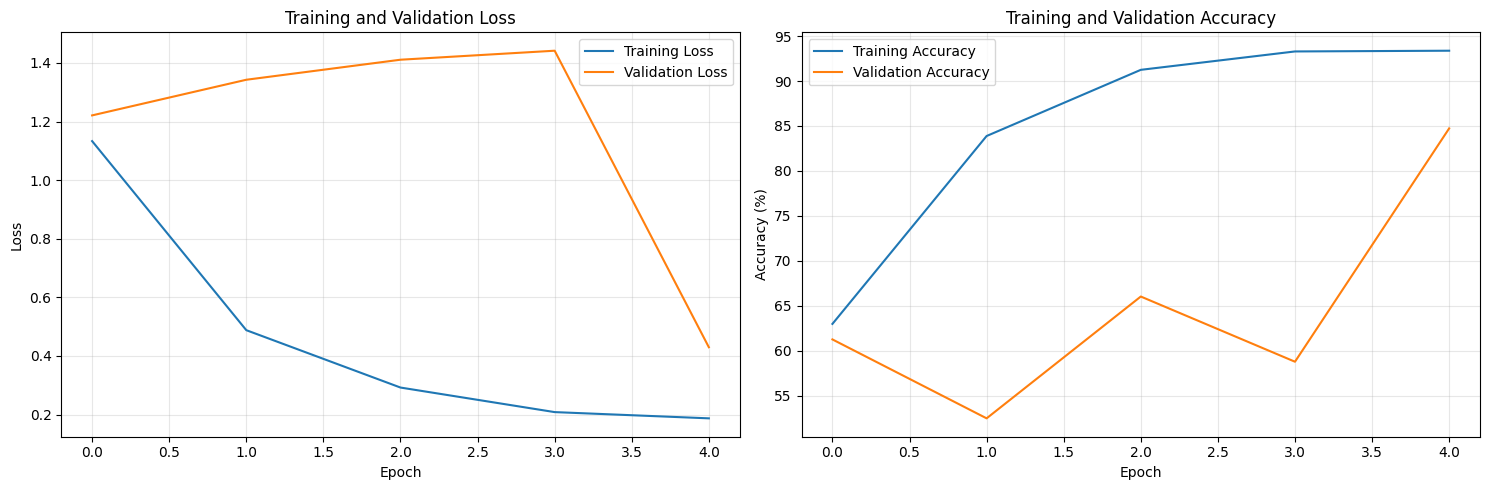


FINAL RESULTS SUMMARY - ATTENTION CNN (CBAM)
Training Time: 1955.60 seconds
Inference Time: 34.22 seconds
Test Accuracy: 82.29%
Weighted Precision: 0.8700
Weighted Recall: 0.8229
Weighted F1-Score: 0.8306
ROC AUC Score: 0.9947
Number of Parameters: 2,140,568
Attention Mechanism: CBAM

Results saved to CSV files

TASK 4 COMPLETED SUCCESSFULLY


In [1]:
# -*- coding: utf-8 -*-
"""
Attention-Enhanced CNN Model for Rare and Endangered Medicinal Plants Classification
Task 4 of CSE366 Mini Project
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import time
import os
from PIL import Image
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# Data Preprocessing Class
# =============================================================================

class PlantDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        
        # Load images and labels
        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(class_dir, img_file))
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

class DataPreprocessor:
    def __init__(self, data_path, img_size=128, batch_size=32):
        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        
        # Data transforms
        self.train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.val_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
    def prepare_dataloaders(self, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
        """Prepare train, validation, and test dataloaders"""
        dataset = PlantDataset(self.data_path, transform=self.train_transform)
        
        # Calculate split sizes
        total_size = len(dataset)
        train_size = int(train_ratio * total_size)
        val_size = int(val_ratio * total_size)
        test_size = total_size - train_size - val_size
        
        # Split dataset
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, [train_size, val_size, test_size]
        )
        
        # Apply validation transform to val and test datasets
        val_dataset.dataset.transform = self.val_transform
        test_dataset.dataset.transform = self.val_transform
        
        # Create dataloaders
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        self.class_names = dataset.classes
        
        print(f"Total samples: {total_size}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Validation samples: {len(val_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        print(f"Number of classes: {len(self.class_names)}")
        print(f"Classes: {self.class_names}")
        
        return train_loader, val_loader, test_loader

# =============================================================================
# Attention Modules Implementation
# =============================================================================

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block"""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = self.global_avg_pool(x).view(batch_size, channels)
        y = self.fc(y).view(batch_size, channels, 1, 1)
        return x * y.expand_as(x)

class CBAMBlock(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        
        # Channel attention
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        
        # Spatial attention
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca
        
        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa_input = torch.cat([avg_out, max_out], dim=1)
        sa = self.spatial_attention(sa_input)
        x = x * sa
        
        return x

class SelfAttention(nn.Module):
    """Self-Attention Module"""
    def __init__(self, in_dim):
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)
        
    def forward(self, x):
        batch_size, C, width, height = x.size()
        
        # Projections
        proj_query = self.query_conv(x).view(batch_size, -1, width * height).permute(0, 2, 1)
        proj_key = self.key_conv(x).view(batch_size, -1, width * height)
        
        # Attention map
        energy = torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy)
        
        # Value projection and output
        proj_value = self.value_conv(x).view(batch_size, -1, width * height)
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(batch_size, C, width, height)
        
        return self.gamma * out + x

# =============================================================================
# Attention-Enhanced CNN Model
# =============================================================================

class AttentionEnhancedCNN(nn.Module):
    def __init__(self, num_classes=16, dropout_rate=0.5, attention_type='CBAM'):
        super(AttentionEnhancedCNN, self).__init__()
        self.attention_type = attention_type
        
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.attention1 = self._create_attention(64, attention_type)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.attention2 = self._create_attention(128, attention_type)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.attention3 = self._create_attention(256, attention_type)
        
        # Convolutional Block 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.attention4 = self._create_attention(512, attention_type)
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(512, 1024)
        self.bn5 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, num_classes)
        
        # Regularization
        self.dropout = nn.Dropout(dropout_rate)
        self.pool = nn.MaxPool2d(2, 2)
        
    def _create_attention(self, channels, attention_type):
        if attention_type == 'SE':
            return SEBlock(channels)
        elif attention_type == 'CBAM':
            return CBAMBlock(channels)
        elif attention_type == 'SelfAttention':
            return SelfAttention(channels)
        else:
            return nn.Identity()
        
    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Attention -> Pool
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.attention1(x)
        x = self.pool(x)
        
        # Block 2: Conv -> BN -> ReLU -> Attention -> Pool
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.attention2(x)
        x = self.pool(x)
        
        # Block 3: Conv -> BN -> ReLU -> Attention -> Pool
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.attention3(x)
        x = self.pool(x)
        
        # Block 4: Conv -> BN -> ReLU -> Attention -> Pool
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.attention4(x)
        x = self.pool(x)
        
        # Global Average Pooling
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = torch.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# =============================================================================
# Training Class
# =============================================================================

class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device, scheduler=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.scheduler = scheduler
        
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc='Training')
        for batch_idx, (data, targets) in enumerate(pbar):
            data, targets = data.to(self.device), targets.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def validate_epoch(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def train(self, epochs, patience=10):
        best_val_acc = 0
        patience_counter = 0
        start_time = time.time()
        
        print(f"{'Epoch':^6} | {'Train Loss':^12} | {'Train Acc':^10} | {'Val Loss':^12} | {'Val Acc':^10} | {'Time':^8}")
        print("-" * 70)
        
        for epoch in range(epochs):
            epoch_start = time.time()
            
            # Training
            train_loss, train_acc = self.train_epoch()
            
            # Validation
            val_loss, val_acc = self.validate_epoch()
            
            # Learning rate scheduling
            if self.scheduler:
                self.scheduler.step(val_acc)
            
            # Save metrics
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            epoch_time = time.time() - epoch_start
            
            print(f"{epoch+1:^6} | {train_loss:^12.4f} | {train_acc:^10.2f} | {val_loss:^12.4f} | {val_acc:^10.2f} | {epoch_time:^8.2f}")
            
            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_attention_cnn.pth')
                print(f"✓ New best model saved with validation accuracy: {val_acc:.2f}%")
            else:
                patience_counter += 1
            
            # Early stopping
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
        
        total_time = time.time() - start_time
        print(f"\nTraining completed in {total_time:.2f} seconds")
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        
        return total_time

# =============================================================================
# Evaluation Class
# =============================================================================

class ModelEvaluator:
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names
        
    def evaluate_model(self):
        self.model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        
        start_time = time.time()
        
        with torch.no_grad():
            for data, targets in tqdm(self.test_loader, desc='Evaluating'):
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
        
        inference_time = time.time() - start_time
        accuracy = 100. * np.sum(np.array(all_predictions) == np.array(all_targets)) / len(all_targets)
        
        return all_predictions, all_targets, all_probabilities, accuracy, inference_time
    
    def calculate_detailed_metrics(self, predictions, targets):
        # Classification report
        report = classification_report(targets, predictions, target_names=self.class_names, output_dict=True)
        
        # Convert to DataFrame
        metrics_data = []
        for class_name in self.class_names:
            metrics_data.append({
                'Class': class_name,
                'Precision': report[class_name]['precision'],
                'Recall': report[class_name]['recall'],
                'F1-Score': report[class_name]['f1-score'],
                'Support': report[class_name]['support']
            })
        
        metrics_df = pd.DataFrame(metrics_data)
        
        # Overall metrics
        overall_precision = report['weighted avg']['precision']
        overall_recall = report['weighted avg']['recall']
        overall_f1 = report['weighted avg']['f1-score']
        
        # Print detailed report
        print("\nDetailed Classification Report:")
        print(classification_report(targets, predictions, target_names=self.class_names))
        
        return metrics_df, overall_precision, overall_recall, overall_f1
    
    def plot_confusion_matrix(self, predictions, targets):
        cm = confusion_matrix(targets, predictions)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=self.class_names, 
                   yticklabels=self.class_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        return cm
    
    def plot_roc_curves(self, targets, probabilities):
        # Convert to one-hot encoding
        targets_onehot = np.eye(len(self.class_names))[targets]
        probabilities = np.array(probabilities)
        
        # Calculate ROC AUC for each class
        fpr = {}
        tpr = {}
        roc_auc = {}
        
        plt.figure(figsize=(10, 8))
        
        for i in range(len(self.class_names)):
            fpr[i], tpr[i], _ = roc_curve(targets_onehot[:, i], probabilities[:, i])
            roc_auc[i] = roc_auc_score(targets_onehot[:, i], probabilities[:, i])
            
            plt.plot(fpr[i], tpr[i], lw=2, 
                    label=f'{self.class_names[i]} (AUC = {roc_auc[i]:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Multi-class')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Calculate macro average AUC
        macro_auc = roc_auc_score(targets_onehot, probabilities, average='macro')
        print(f"Macro Average ROC AUC: {macro_auc:.4f}")
        
        return macro_auc
    
    def plot_training_history(self, trainer):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Plot losses
        ax1.plot(trainer.train_losses, label='Training Loss')
        ax1.plot(trainer.val_losses, label='Validation Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot accuracies
        ax2.plot(trainer.train_accuracies, label='Training Accuracy')
        ax2.plot(trainer.val_accuracies, label='Validation Accuracy')
        ax2.set_title('Training and Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# =============================================================================
# Main Execution for Task 4
# =============================================================================

def run_attention_cnn(attention_type='CBAM'):
    """Main function to run Attention-Enhanced CNN model"""
    print("=" * 60)
    print(f"TASK 4: Attention-Enhanced CNN ({attention_type})")
    print("=" * 60)
    
    # Configuration
    DATA_PATH = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
    IMG_SIZE = 128
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 5
    PATIENCE = 3
    
    # Step 1: Data Preparation
    print("\n1. Preparing Data...")
    preprocessor = DataPreprocessor(DATA_PATH, IMG_SIZE, BATCH_SIZE)
    train_loader, val_loader, test_loader = preprocessor.prepare_dataloaders()
    class_names = preprocessor.class_names
    
    # Step 2: Model Initialization
    print(f"\n2. Initializing Attention-Enhanced CNN ({attention_type})...")
    model = AttentionEnhancedCNN(num_classes=len(class_names), 
                               dropout_rate=0.5, 
                               attention_type=attention_type)
    model = model.to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Step 3: Training Setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)
    
    # Step 4: Training
    print("\n3. Starting Training...")
    trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, device, scheduler)
    training_time = trainer.train(EPOCHS, PATIENCE)
    
    # Step 5: Load Best Model and Evaluate
    print("\n4. Loading Best Model and Evaluating...")
    model.load_state_dict(torch.load('best_attention_cnn.pth'))
    
    evaluator = ModelEvaluator(model, test_loader, device, class_names)
    predictions, targets, probabilities, test_accuracy, inference_time = evaluator.evaluate_model()
    
    # Step 6: Generate Comprehensive Reports
    print("\n5. Generating Evaluation Reports...")
    
    # Detailed metrics
    metrics_df, overall_precision, overall_recall, overall_f1 = evaluator.calculate_detailed_metrics(predictions, targets)
    
    # Confusion Matrix
    cm = evaluator.plot_confusion_matrix(predictions, targets)
    
    # ROC Curves
    roc_auc = evaluator.plot_roc_curves(targets, probabilities)
    
    # Training History
    evaluator.plot_training_history(trainer)
    
    # Step 7: Final Summary
    print("\n" + "=" * 60)
    print(f"FINAL RESULTS SUMMARY - ATTENTION CNN ({attention_type})")
    print("=" * 60)
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Weighted Precision: {overall_precision:.4f}")
    print(f"Weighted Recall: {overall_recall:.4f}")
    print(f"Weighted F1-Score: {overall_f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Number of Parameters: {total_params:,}")
    print(f"Attention Mechanism: {attention_type}")
    
    # Save results
    results_df = pd.DataFrame({
        'Model': [f'Attention-CNN-{attention_type}'],
        'Training_Time': [training_time],
        'Inference_Time': [inference_time],
        'Test_Accuracy': [test_accuracy],
        'Precision': [overall_precision],
        'Recall': [overall_recall],
        'F1_Score': [overall_f1],
        'ROC_AUC': [roc_auc],
        'Parameters': [total_params],
        'Attention_Type': [attention_type]
    })
    
    results_df.to_csv(f'attention_cnn_{attention_type.lower()}_results.csv', index=False)
    metrics_df.to_csv(f'attention_cnn_{attention_type.lower()}_class_metrics.csv', index=False)
    
    print("\nResults saved to CSV files")
    
    return results_df, metrics_df

# =============================================================================
# Task 4 Only Execution
# =============================================================================

def run_task4_only():
    """Run only Task 4 (Attention-Enhanced CNN) without comparison to Task 3"""
    print("CSE366 Mini Project: Medicinal Plants Classification")
    print("TASK 4: Attention-Enhanced CNN")
    print("=" * 60)
    
    # Run Attention-Enhanced CNN (Task 4)
    attention_results, attention_metrics = run_attention_cnn('CBAM')
    
    print("\n" + "=" * 60)
    print("TASK 4 COMPLETED SUCCESSFULLY")
    print("=" * 60)
    
    return attention_results, attention_metrics

# Execute Task 4 only
if __name__ == "__main__":
    attention_results, attention_metrics = run_task4_only()